<a href="https://colab.research.google.com/github/SiddhantMS/PML-Practical-Machine-Learning-/blob/main/Sudeep_Bharghav_PML_simple_regretion_Day_1%262%263.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

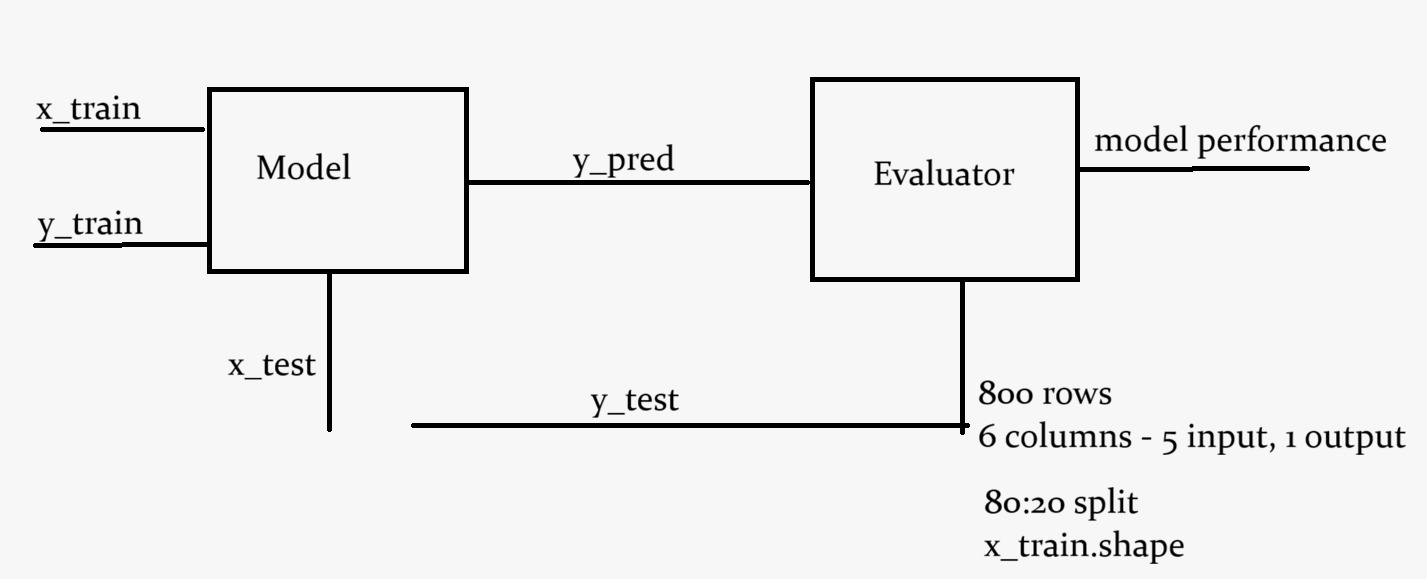

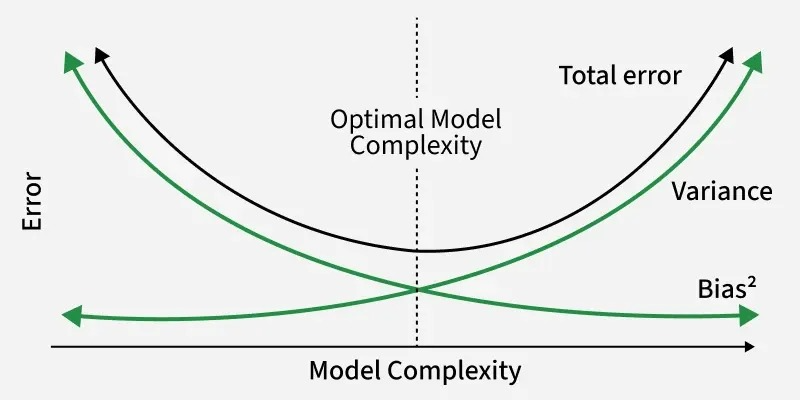

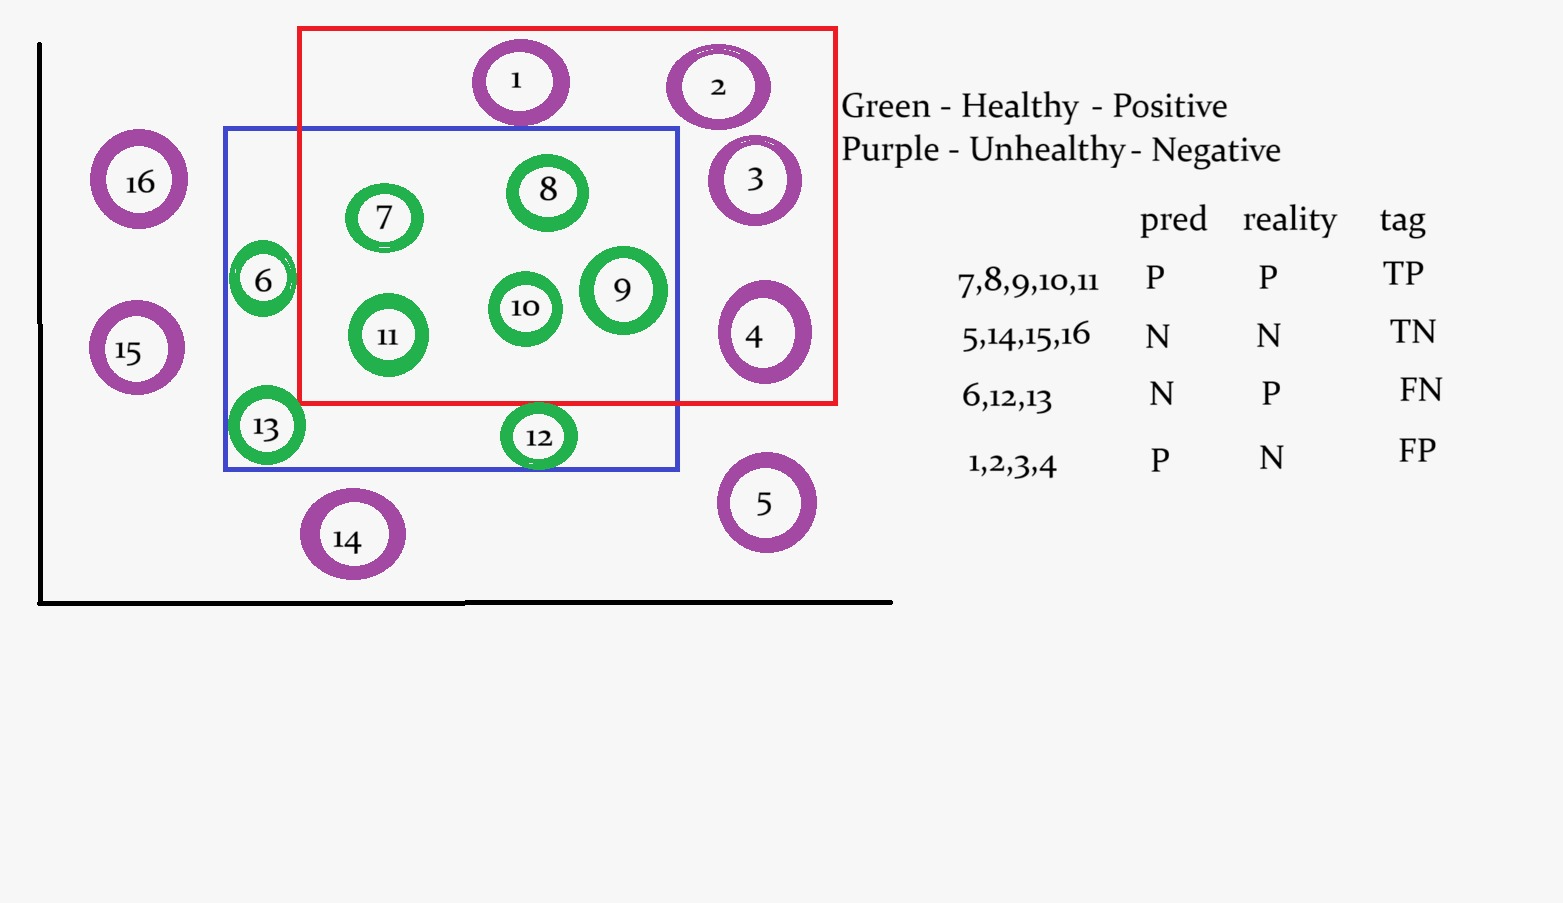

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon
from sklearn.model_selection import train_test_split
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split

In [ ]:
import os
os.chdir(r"/content/drive/MyDrive/stats")
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#import dataset
df = pd.read_excel('CDAC_DataBook.xlsx',sheet_name='faithful')

In [ ]:
# wating is the predictor
# eruptions is the response

In [ ]:
import scipy.stats
scipy.stats.pearsonr(df.eruptions,df.waiting)

PearsonRResult(statistic=np.float64(0.9008111683218132), pvalue=np.float64(8.129958506615525e-100))

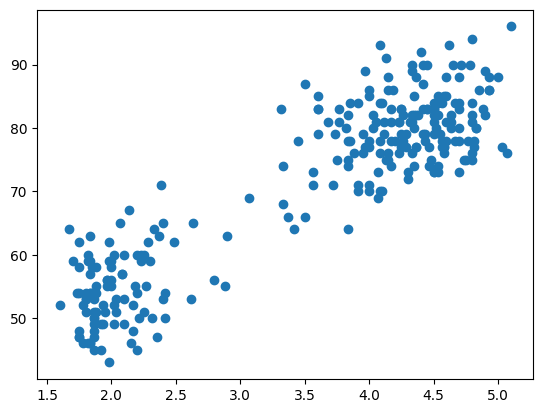

In [ ]:
plt.scatter(df.eruptions,df.waiting)

In [ ]:
#split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.waiting,df.eruptions, test_size=0.3,random_state=20)
#here we split 70:30

In [ ]:
x_train.head()

,waiting
182,83
248,67
50,75
209,83
200,60


In [ ]:
#comand for modeling
#ass constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

In [ ]:
x_train.head()

,waiting,const
182,83,1.0
248,67,1.0
50,75,1.0
209,83,1.0
200,60,1.0


In [ ]:
# prepare the model /model building
mod1 = sm.OLS(y_train,x_train).fit()

# ols stands for ordinary least square

In [ ]:
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              eruptions   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     771.1
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.94e-68
Time:                        11:49:31   Log-Likelihood:                -140.85
No. Observations:                 190   AIC:                             285.7
Df Residuals:                     188   BIC:                             292.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
waiting        0.0782      0.003     27.768      0.0

In [ ]:
'''
what is r-squared:0.804
80.4 % of varation being explained by model
'''

'\nwhat is r-squared:0.804\n80.4 % of varation being explained by model\n'

In [ ]:
 '''
  y=mx+c
               coef
waiting        0.0782     --> this is m
const         -2.0814     --> this is c

eruptions = 0.0782 * waiting-2.080

sign of coef will decide the output of factor

R-squared:(coeff of determination)--> it represents the percentage of
variation in the data explained by the model

coeff of wating (.0782) is the increase in the responce when the
 predector wating is increase by one unit

'''
'''

            P>|t|
waiting     0.000       this is p-value
const       0.000
'''
'''
             [0.025      0.975]  --> this is interval estimates for coefficent
waiting       0.073       0.084
const         -2.481      -1.682
'''

'\n            [0.025      0.975]  --> this is interval estimates for coefficent\nwaiting       0.073       0.084\nconst         -2.481      -1.682\n'

In [ ]:
'''
step1 what is null hypothesis
step2 what is p-value
step3 what is result? (reject or not reject)
step4 what is conclusion (what is effect is there or not)
step5
'''

'\nstep1 what is null hypothesis\nstep2 what is p-value\nstep3 what is result? (reject or not reject)\nstep4 what is conclusion (what is effect is there or not)\nstep5\n'

In [ ]:
'''
our hypothsis Ho(m)=0
p-value- 0.00 it is less than .05
so we rejected
m cannot be cunsider 0
m cannot be ignored
means m is influsing y
also in our interval estimate there is no 0 value
means chainging the waithing time will change eruptions
'''

'\nour hypothsis Ho(m)=0\np-value- 0.00 it is less than .05\nso we rejected\nm cannot be cunsider 0\nm cannot be ignored\nmeans m is influsing y\nalso in our interval estimate there is no 0 value\nmeans chainging the waithing time will change eruptions\n'

In [ ]:
z= 0.000-0.0782/0.003
z  # thsi is t we are calculating z

-26.066666666666666

In [ ]:
'''
our hypothsis Ho(c)=0
p-value- 0.00
so we rejected
c cannot be cunsider 0
means c is influsing y
'''

'\nour hypothsis Ho(c)=0\np-value- 0.00\nso we rejected\nc cannot be cunsider 0\nmeans c is influsing y\n'

In [ ]:
z=0.00-(-2.0814)/0.203
z

10.25320197044335

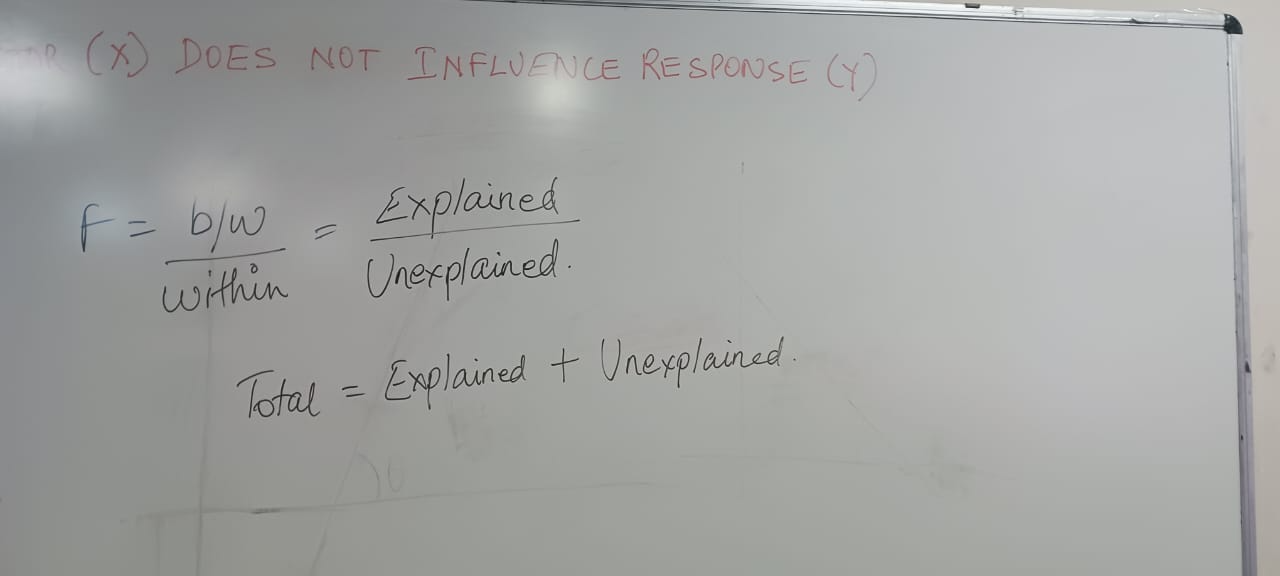

In [ ]:
y_preds = mod1.predict(x_train)
y_preds.head()

,0
182,4.411512
248,3.159859
50,3.785686
209,4.411512
200,2.612262


In [ ]:
y_train.head()
#here we are comparing our model prediction with our answer traindata

,eruptions
182,4.250
248,2.133
50,4.800
209,4.500
200,2.100


In [ ]:
'''
by comparing
t_prep 182	4.411512
t_test 182	4.250
these value are not same that means there is error
we also called residuals
'''

'\nby comparing\nt_prep 182\t4.411512\nt_test 182\t4.250\nthese value are not same that means there is error\nwe also called residuals\n'

calculation to find the r-square

In [ ]:
'''R-squared:(coeff of determination)--> it represents the percentage of
variation in the data explained by the model

coeff of wating (.0782) is the increase in the responce when the
 predector wating is increase by one unit'''

'R-squared:(coeff of determination)--> it represents the percentage of\nvariation in the data explained by the model\n\ncoeff of wating (.0782) is the increase in the responce when the\n predector wating is increase by one unit'

In [ ]:
residuals = y_train-y_preds
#if we take total it will be 0
# for that we take square and add of it also called
#  sum of square residuals

(array([ 5.,  9., 18., 30., 25., 36., 30., 20., 13.,  4.]),
 array([-1.25817472, -1.01204863, -0.76592254, -0.51979646, -0.27367037,
        -0.02754428,  0.21858181,  0.4647079 ,  0.71083398,  0.95696007,
         1.20308616]),
 <BarContainer object of 10 artists>)

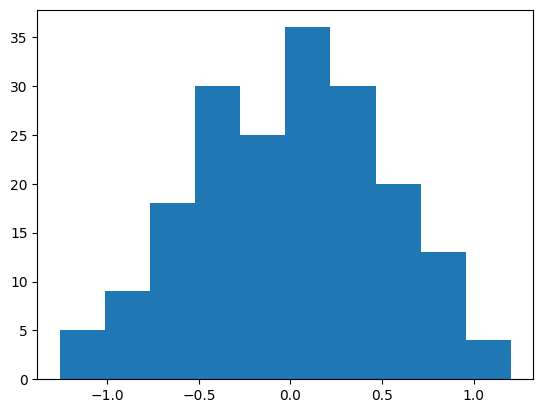

In [ ]:
plt.hist(residuals)

In [ ]:
sse = sum(residuals**2)
sse  # why difference is comming what is 48.99679457123917 this value
# this is unexplained variation

48.99679457123917

In [ ]:
#SSE - stands for sum square of error/reseduals
#SST - sum square of total variation
#SSR - sum square of Regression or Explined variation

In [ ]:
sst = sum((y_train-np.mean(y_train))**2)
sst
# why difference is comming what is 249.95112065263157 this value
#total varation


249.95112065263157

In [ ]:
ssr = sst-sse
ssr  # this is value of explined variation

200.9543260813924

In [ ]:
ssr/sst  # this no is nothing but your  --->  r-square
#what fraction ot total is being explained by model

0.803974495320098

In [ ]:
#((ssr)/('''degrees of fredom'''))/(sse/('''defrees of freddom'''))

In [ ]:
y_train.shape

(190,)

In [ ]:
#no of values = 190
# total dof = 189
# dof for regression model = 2-1 = 1
# dof for error or residual = 189-1 = 188

'''
No. Observations:                 190
Df Residuals:                     188
Df Model:                           1
'''

'\nNo. Observations:                 190\nDf Residuals:                     188\nDf Model:                           1\n'

In [ ]:
F = ((ssr)/(1))/(sse/(188))
F  # this is  F-statistic:   value in table
# this f value is useful to calculate the p-value

771.0588750529828

MULTIPLE LEANEAR REGRESSION

===============================================================================================================================================================================================================

**SK-LEARN **

=====================================================================================================================================================================================================================

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
#CREATING A INSTANCE FOR FUNCTION LEANEAR REGRESSION
regr1 = LinearRegression()

In [ ]:
#split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.waiting,df.eruptions, test_size=0.3,random_state=20)
#here we split 70:30

In [ ]:
#mod_sk = regr1.fit(x_train,y_train)
#ValueError: Expected a 2-dimensional container
#but got <class 'pandas.core.series.Series'> instead.
#Pass a DataFrame containing a single row (i.e. single sample)
#or a single column (i.e. single feature) instead.

In [ ]:
#here we are geting because input rows are not correct we have to reshape it

In [ ]:
x_train = np.array(x_train).reshape(-1,1)
y_train = np.array(y_train).reshape(-1,1)

In [ ]:
#create the model
regr1.fit(x_train,y_train)

LinearRegression()

In [ ]:
#values for the coeffiients
regr1.coef_

array([[0.07822826]])

In [ ]:
# value for the intercept
regr1.intercept_

array([-2.08143394])

In [ ]:
# R2(based on the training set)
regr1.score(x_train,y_train)

0.803974495320098

In [ ]:
#making predictions
y_pred = regr1.predict(x_train)
y_pred

array([[4.41151166],
       [3.1598595 ],
       [3.78568558],
       [4.41151166],
       [2.61226168],
       [4.64619644],
       [2.92517472],
       [4.25505514],
       [2.61226168],
       [2.06466386],
       [1.82997907],
       [4.80265296],
       [3.08163124],
       [4.3332834 ],
       [3.86391384],
       [2.84694646],
       [3.00340298],
       [3.31631602],
       [1.51706603],
       [4.02037036],
       [3.62922906],
       [4.48973992],
       [4.56796818],
       [2.84694646],
       [1.51706603],
       [1.9864356 ],
       [3.31631602],
       [4.95910948],
       [3.70745732],
       [4.02037036],
       [2.61226168],
       [4.02037036],
       [4.02037036],
       [4.48973992],
       [4.7244247 ],
       [3.9421421 ],
       [4.88088122],
       [2.53403342],
       [3.5510008 ],
       [4.48973992],
       [2.7687182 ],
       [3.47277254],
       [4.56796818],
       [4.02037036],
       [4.25505514],
       [2.7687182 ],
       [4.95910948],
       [5.115

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
#calculate the mean square error between y_pred and y_train
mse1 = mean_squared_error(y_pred,y_train)

In [ ]:
mse1

0.2578778661644167

In [ ]:
'''
valadition set command
this is not on stats model we can only do in sklearn
'''

'\nvaladition set command\nthis is not on stats model we can only do in sklearn\n'

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
cross_val_score(regr1,x_train,y_train,scoring='neg_mean_squared_error',cv=5)

array([-0.27359473, -0.24925173, -0.25445376, -0.25548319, -0.27051377])

In [ ]:
#corelation coeffecient

In [ ]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'stackloss')


# Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('StackLoss', axis=1),df.StackLoss, test_size=0.1, random_state=20)

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              StackLoss   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     46.11
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.67e-07
Time:                        11:49:31   Log-Likelihood:                -45.877
No. Observations:                  18   AIC:                             99.75
Df Residuals:                      14   BIC:                             103.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
AirFlow        0.7001      0.152      4.592      0.0

In [ ]:
from sklearn.linear_model import LinearRegression

df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'stackloss')
x_train, x_test, y_train, y_test = train_test_split(df.drop('StackLoss', axis=1),df.StackLoss, test_size=0.1, random_state=20)

# Creating an instance for the function
regr1 = LinearRegression()

regr1.fit(x_train,y_train)

regr1.intercept_  #INTERSEPT
regr1.coef_       #COEFFIIENTS
regr1.feature_names_in_ # names of features
regr1.score(x_train,y_train) #r2
regr1.predict(x_test) #predict


array([10.83134469, 14.08460126, 10.34327252])

another model

In [ ]:
from sklearn.preprocessing import StandardScaler
scl = StandardScaler() #instance for making for standardscalar

In [ ]:
x_train = scl.fit_transform(x_train)  # only for traning we do fit and transform
x_test = scl.transform(x_test)    # here testing data we are not fiting we do only transform

In [ ]:
x_train = pd.DataFrame(x_train,columns=['AirFlow','WaterTemp','AcidConc'])
x_test = pd.DataFrame(x_test,columns=['AirFlow','WaterTemp','AcidConc'])
regr2 = LinearRegression()
regr2.fit(x_train,y_train)


LinearRegression()

In [ ]:
regr2.intercept_ #intercept

np.float64(18.666666666666668)

In [ ]:
regr2.coef_ #coefficients

array([ 6.19332814,  4.40861726, -0.90286981])

In [ ]:
# regr2.feature_names_in_ # This attribute is not available as x_train was a numpy array
# The original feature names were from df.drop('StackLoss', axis=1)


In [ ]:
#whern the data are standaradise the mean becom 0 and stand dev become 1 but all the attr

In [ ]:
'''
when the values of percticular are standardise
mean become zero and standard dev become one but
the distibution of values of histrogram do not
change '''

'\nwhen the values of percticular are standardise \nmean become zero and standard dev become one but \nthe distibution of values of histrogram do not \nchange '

In [ ]:
x_train.head()


,AirFlow,WaterTemp,AcidConc
0,0.018841,0.204124,-0.169638
1,2.053681,1.735055,0.084819
2,-0.433346,-1.020621,-1.441921
3,-0.433346,-0.714435,1.357102
4,-1.337719,-0.714435,-2.205291


========================================================================================================================================================================================

                  **categorical regression**

========================================================================================================================================================================================

model-1

In [ ]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'salaries')

df = df[['yrs_service','gender','salary']]

gender_dum = pd.get_dummies(df.gender,drop_first=True).astype(int)

df = pd.concat([df,gender_dum], axis=1)

df = df.drop('gender', axis=1)


# Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('salary', axis=1),df.salary, test_size=0.2, random_state=20)

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     21.52
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.75e-09
Time:                        11:49:32   Log-Likelihood:                -3698.4
No. Observations:                 317   AIC:                             7403.
Df Residuals:                     314   BIC:                             7414.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
yrs_service   701.6382    125.946      5.571      

In [ ]:
Male         1.368e+04   5434.664      2.517      0.012    2985.362    2.44e+04   5434.664      2.517      0.012    2985.362    2.44e+04

SyntaxError: invalid syntax (935467136.py, line 1)

In [ ]:
the nulll hypothsis could (refrence event)with resp to femalil if a male is selected then it does not influence salary
i:e any gender we are picking up there will not be infuence the salary

In [ ]:
in simple words gender does not influence salary

In [ ]:
p-value is zero so we rejet the null hypothersis

In [ ]:
constant term infulence the salary
constant term = 88570 indicates the salary of person for hum years_service is equal to zero and male equal to zero which means the gender equal to female which is refrance Level
so the starting salary for female will be 88570
Male         1.368e+04  --> from respect to femails males are geting 13680 more salary than female
the starting salay for male will be 13680+88570

model-2

In [ ]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'salaries')

df = df[['yrs_service','gender','salary']]

gender_dum = pd.get_dummies(df.gender,drop_first=True).astype(int)

df = pd.concat([df,gender_dum], axis=1)

df = df.drop('gender', axis=1)


# Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('salary', axis=1),df.salary, test_size=0.2, random_state=20)

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     21.52
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.75e-09
Time:                        11:49:41   Log-Likelihood:                -3698.4
No. Observations:                 317   AIC:                             7403.
Df Residuals:                     314   BIC:                             7414.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
yrs_service   701.6382    125.946      5.571      

In [ ]:
df = pd.read_excel('SalesData.xlsx')


region_dum = pd.get_dummies(df['Region'],drop_first=True).astype(int)

df = pd.concat([df,region_dum], axis=1)

df = df.drop('Region', axis=1)


# Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('Sales', axis=1),df.Sales, test_size=0.2, random_state=20)

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     1889.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:18:26   Log-Likelihood:                -5940.0
No. Observations:                1200   AIC:                         1.189e+04
Df Residuals:                    1194   BIC:                         1.192e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Ad_Budget      3.4866      0.037     93.243      0.0